# Kinematic Features (Displacement, Velocity, and Acceleration)

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from pose_dynamics.projects.mirror_game.pipeline import *
from pose_dynamics.features.linear_features import (
    extract_kinematics_per_frame,
    summarise_scalar_timeseries,
)

KEYPOINTS_OF_INTEREST = [
    22,          # left ankle
    23,         # right ankle
    16,        # left hand
    17,        # right hand
    5,         # nose
]

N_KEYPOINTS = 38
XYZ_COLS = [f"{axis}{k}" for k in range(N_KEYPOINTS) for axis in ("x", "y", "z")]
FPS = 30.0

PREPROC_PATH = Path(
    "/Users/cartersale/Documents/Pose_Dynamics/projects/mirror_game/data/preprocessed/mirror_game_preprocessed.csv"
)

df_all = pd.read_csv(PREPROC_PATH)
print(df_all.shape)

missing = [c for c in XYZ_COLS if c not in df_all.columns]
if missing:
    raise ValueError(f"Missing pose columns: {missing[:10]}")

def df_to_pose_tensor(df, xyz_cols=XYZ_COLS, n_keypoints=N_KEYPOINTS):
    arr = df[xyz_cols].to_numpy(dtype=float)
    T, F = arr.shape
    assert F == n_keypoints * 3, f"Expected {n_keypoints*3} features, got {F}"
    return arr.reshape(T, n_keypoints, 3)


(455138, 124)


In [2]:
group_cols = ["pair_trial", "party"]
meta_cols = group_cols + ["Pair", "Trial", "Condition", "Leader", "Role"]

features_rows = []

for (pair_trial, party), df_trial in df_all.groupby(group_cols):
    df_trial = df_trial.sort_values("time_s") if "time_s" in df_trial.columns else df_trial.copy()

    coords = df_to_pose_tensor(df_trial)  # (T, 38, 3)

    # subset to keypoints of interest, in fixed order
    kp_indices = KEYPOINTS_OF_INTEREST
    coords_sub = coords[:, kp_indices, :]   # (T, n_sub, 3)

    kin = extract_kinematics_per_frame(coords_sub, fps=FPS)
    speed = kin["speed"]              # (T-1, n_sub)
    accel = kin["acceleration"]       # (T-2, n_sub)

    row = {}

    # meta
    meta = df_trial.iloc[0]
    for col in meta_cols:
        if col in df_trial.columns:
            row[col] = meta[col]

    # per-keypoint stats (collapse over time only, keep keypoints separate)
    for sub_idx, kp_idx in enumerate(kp_indices):
        label = KEYPOINT_MAPPING[kp_idx]  # e.g. "left_wrist"

        disp_stats = summarise_scalar_timeseries(
            kin["displacement"][:, sub_idx],   # (T-1,)
            axes=(0,),
            prefix=f"{label}_displacement",
            stats=("mean", "std", "max", "rms"),
        )

        speed_stats = summarise_scalar_timeseries(
            speed[:, sub_idx],   # (T-1,)
            axes=(0,),
            prefix=f"{label}_speed",
            stats=("mean", "std", "max", "rms"),
        )
        accel_stats = summarise_scalar_timeseries(
            accel[:, sub_idx],   # (T-2,)
            axes=(0,),
            prefix=f"{label}_accel",
            stats=("mean", "std", "max", "rms"),
        )

        row.update(speed_stats)
        row.update(accel_stats)
        row.update(disp_stats)

    row.update(
        summarise_scalar_timeseries(
            kin["displacement"], axes=(0, 1), prefix="subset_displacement", stats=("mean", "std", "max","rms")
        )
    )
    
    row.update(
        summarise_scalar_timeseries(
            speed, axes=(0, 1), prefix="subset_speed", stats=("mean", "std", "max","rms")
        )
    )
    row.update(
        summarise_scalar_timeseries(
            accel, axes=(0, 1), prefix="subset_accel", stats=("mean", "std", "max","rms")
        )
    )

    features_rows.append(row)

df_lin_subset = pd.DataFrame(features_rows)
print(df_lin_subset.shape)
df_lin_subset.head()


(432, 79)


,pair_trial,party,Pair,Trial,Condition,Leader,Role,left_ankle_speed_mean,left_ankle_speed_std,left_ankle_speed_max,...,subset_displacement_max,subset_displacement_rms,subset_speed_mean,subset_speed_std,subset_speed_max,subset_speed_rms,subset_accel_mean,subset_accel_std,subset_accel_max,subset_accel_rms
0,P001_T1,P1,1,1,b2b,P1,Leader,0.410793,0.442962,3.489469,...,0.189439,0.018686,0.335707,0.448957,5.683179,0.560590,3.278863,5.737186,98.130051,6.608044
1,P001_T1,P2,1,1,b2b,P1,Follower,0.170406,0.215651,1.232953,...,0.186066,0.016247,0.264564,0.409370,5.581967,0.487419,2.404149,4.521600,81.418022,5.121016
2,P001_T10,P1,1,10,uni,P2,Follower,0.433125,0.441569,2.801322,...,0.164589,0.027074,0.511422,0.630983,4.937665,0.812214,4.634589,6.319548,61.682099,7.836843
3,P001_T10,P2,1,10,uni,P2,Leader,0.419029,0.451187,2.381167,...,0.223201,0.028172,0.516085,0.669285,6.696017,0.845154,4.951539,7.166689,72.967835,8.710865
4,P001_T11,P1,1,11,f2f,P2,Follower,0.409322,0.447004,2.431256,...,0.174125,0.024046,0.448443,0.565051,5.223746,0.721377,3.985186,5.733531,62.834636,6.982484


In [3]:
OUT_PATH = "/Users/cartersale/Documents/Pose_Dynamics/projects/mirror_game/data/features/mirror_game_linear_features_subset.csv"
df_lin_subset.to_csv(OUT_PATH, index=False)
print(f"Saved subset linear features to:\n{OUT_PATH}")

Saved subset linear features to:
/Users/cartersale/Documents/Pose_Dynamics/projects/mirror_game/data/features/mirror_game_linear_features_subset.csv


## Stats

In [4]:
import pandas as pd
from pathlib import Path

import rpy2.robjects as ro
from rpy2.robjects import pandas2ri, conversion

# --- Load data in Python ---
df = pd.read_csv(
    "/Users/cartersale/Documents/Pose_Dynamics/projects/mirror_game/data/features/mirror_game_linear_features_subset.csv"
)

# --- Send df to R (no deprecated activate) ---
with conversion.localconverter(ro.default_converter + pandas2ri.converter):
    rdf = conversion.py2rpy(df)

ro.globalenv["df"] = rdf

# --- Load R packages ---
ro.r("library(lme4)")
ro.r("library(lmerTest)")

# --- Make sure R knows the right types ---
ro.r('''
df$Condition <- factor(df$Condition, levels = c("b2b","uni","f2f"))
df$Role      <- factor(df$Role)
df$Pair      <- factor(df$Pair)
df$party     <- factor(df$party)
df$Trial     <- as.numeric(df$Trial)
''')

# --- Define model runner in R: return the model object ---
ro.r('''
run_model <- function(feature_name) {
    form <- as.formula(
        paste0(feature_name,
               " ~ Condition + Role + Trial + (1|Pair) + (1|Pair:party)")
    )
    model <- lmer(form, data = df)
    return(model)
}
''')

# --- Define a 'tidy'-like helper in R using base summary() ---
ro.r('''
tidy_fixed <- function(model) {
    s <- summary(model)
    coefs <- as.data.frame(coef(s))
    coefs$term <- rownames(coefs)
    rownames(coefs) <- NULL
    coefs <- coefs[, c("term","Estimate","Std. Error","t value","Pr(>|t|)")]
    names(coefs) <- c("term","estimate","std.error","statistic","p.value")
    return(coefs)
}
''')

FEATURE_TAGS = ["speed", "accel", "disp"]
METRIC_TAGS = ["mean", "rms"]

features = [
    c for c in df.columns
    if any(ft in c for ft in FEATURE_TAGS)
    and any(mt in c for mt in METRIC_TAGS)
]

fixed_effects_list = []

for feat in features:
    print(f"Running model for {feat}...")
    m = ro.r(f'run_model("{feat}")')
    ro.globalenv["m"] = m
    fe = ro.r('tidy_fixed(m)')

    with conversion.localconverter(ro.default_converter + pandas2ri.converter):
        fe_df = conversion.rpy2py(fe)

    fe_df["feature"] = feat
    fixed_effects_list.append(fe_df)

fe_all = pd.concat(fixed_effects_list, ignore_index=True)

# if you just care about the condition terms:
fe_cond = fe_all[fe_all["term"].str.startswith("Condition")]
fe_cond


R callback write-console: Loading required package: Matrix
  
R callback write-console: 
Attaching package: ‘lmerTest’

  
R callback write-console: The following object is masked from ‘package:lme4’:

    lmer

  
R callback write-console: The following object is masked from ‘package:stats’:

    step

  
R callback write-console: boundary (singular) fit: see help('isSingular')
  
R callback write-console: boundary (singular) fit: see help('isSingular')
  


Running model for left_ankle_speed_mean...
Running model for left_ankle_speed_rms...
Running model for left_ankle_accel_mean...
Running model for left_ankle_accel_rms...
Running model for left_ankle_displacement_mean...
Running model for left_ankle_displacement_rms...
Running model for right_ankle_speed_mean...
Running model for right_ankle_speed_rms...


R callback write-console: boundary (singular) fit: see help('isSingular')
  
R callback write-console: boundary (singular) fit: see help('isSingular')
  
R callback write-console: boundary (singular) fit: see help('isSingular')
  
R callback write-console: boundary (singular) fit: see help('isSingular')
  


Running model for right_ankle_accel_mean...
Running model for right_ankle_accel_rms...
Running model for right_ankle_displacement_mean...
Running model for right_ankle_displacement_rms...
Running model for left_wrist_speed_mean...
Running model for left_wrist_speed_rms...
Running model for left_wrist_accel_mean...
Running model for left_wrist_accel_rms...
Running model for left_wrist_displacement_mean...
Running model for left_wrist_displacement_rms...
Running model for right_wrist_speed_mean...
Running model for right_wrist_speed_rms...
Running model for right_wrist_accel_mean...
Running model for right_wrist_accel_rms...
Running model for right_wrist_displacement_mean...
Running model for right_wrist_displacement_rms...
Running model for nose_speed_mean...
Running model for nose_speed_rms...
Running model for nose_accel_mean...
Running model for nose_accel_rms...
Running model for nose_displacement_mean...
Running model for nose_displacement_rms...
Running model for subset_displaceme

,term,estimate,std.error,statistic,p.value,feature
1,Conditionuni,0.053320,0.017029,3.131184,1.871592e-03,left_ankle_speed_mean
2,Conditionf2f,0.085583,0.017029,5.025780,7.638181e-07,left_ankle_speed_mean
6,Conditionuni,0.084256,0.022869,3.684239,2.616206e-04,left_ankle_speed_rms
7,Conditionf2f,0.131013,0.022869,5.728760,2.018021e-08,left_ankle_speed_rms
11,Conditionuni,0.503672,0.166098,3.032384,2.587597e-03,left_ankle_accel_mean
...,...,...,...,...,...,...
167,Conditionf2f,0.141134,0.021079,6.695518,7.465680e-11,subset_speed_rms
171,Conditionuni,0.739797,0.161960,4.567787,6.611245e-06,subset_accel_mean
172,Conditionf2f,0.889245,0.161960,5.490537,7.214530e-08,subset_accel_mean
176,Conditionuni,1.237146,0.252260,4.904259,1.376561e-06,subset_accel_rms


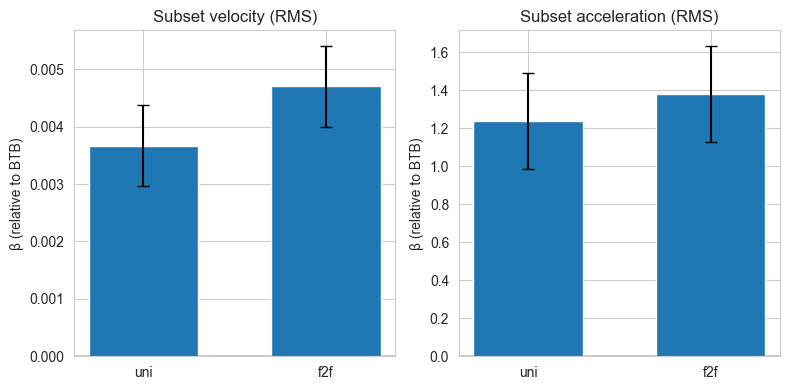

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Filter to the two global metrics we care about ---
metrics_of_interest = ["subset_displacement_rms", "subset_accel_rms"]

fe_lin = fe_cond[fe_cond["feature"].isin(metrics_of_interest)].copy()

# Keep only the Condition terms
fe_lin = fe_lin[fe_lin["term"].isin(["Conditionuni", "Conditionf2f"])]

# Map to nicer labels
term_map = {"Conditionuni": "uni", "Conditionf2f": "f2f"}
metric_label_map = {
    "subset_displacement_rms": "Subset velocity (RMS)",
    "subset_accel_rms": "Subset acceleration (RMS)",
}

fe_lin["Condition"] = fe_lin["term"].map(term_map)
fe_lin["Metric"] = fe_lin["feature"].map(metric_label_map)

# --- 2. Make the two-panel bar plot ---
sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=False)

for ax, metric in zip(axes, metrics_of_interest):
    sub = fe_lin[fe_lin["feature"] == metric]

    # Ensure consistent order
    sub = sub.set_index("Condition").loc[["uni", "f2f"]].reset_index()

    ax.bar(
        x=sub["Condition"],
        height=sub["estimate"],
        yerr=sub["std.error"],
        capsize=4,
        width=0.6,
    )

    ax.axhline(0, color="black", linewidth=1)
    ax.set_xlabel("")
    ax.set_title(metric_label_map[metric])
    ax.set_ylabel("β (relative to BTB)")

plt.tight_layout()
plt.show()
